In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

In [ ]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# convert labels from 2D shape to 1D shape
train_labels = train_labels.flatten()
test_labels = test_labels.flatten()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
# Normalize pixel values from 0–255 to 0–1
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0


In [ ]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]


# 2 Data Augmentation
# This randomly modifies images during training
# Helps prevent overfitting and improves generalization
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),   # randomly flips image left-right during training

    layers.RandomRotation(0.1),      # randomly rotates image up to 10%

    layers.RandomZoom(0.1),       # randomly zooms image up to 10%
])


In [ ]:
model = models.Sequential([

    data_augmentation,     # apply augmentation only during training


    # Conv2D → convolution layer
    # 32 → number of filters (feature detectors)
    # (3,3) → kernel size
    # padding='same' → output size same as input
    # input_shape=(32,32,3) → image size (height, width, RGB channels)

    layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),   # reduce image size by taking maximum value in 2x2 region

    layers.Conv2D(64, (3,3), padding='same'), # second convolution layer with 64 filters
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

   # Dense - Every neuron connects to all neurons from previous layer.
   # Dense - (Fully Connected Layer)It takes all extracted features and answers
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),   # randomly turn off 50% neurons during training (prevents overfitting)


    layers.Dense(10, activation='softmax')    # softmax → converts output into probabilities
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:

#  Compile Model


optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',  # loss function used for integer labels
    metrics=['accuracy']
)


early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,    # wait 5 epochs before stopping
    restore_best_weights=True    # restore weights from best epoch
)

history = model.fit(
    train_images,
    train_labels,
    epochs=15,
    batch_size=64,     # number of images processed at once
    validation_data=(test_images, test_labels),
    callbacks=[early_stop]   # only early stopping
)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 176s 220ms/step - accuracy: 0.2749 - loss: 1.9953 - val_accuracy: 0.4335 - val_loss: 1.5565
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 208s 227ms/step - accuracy: 0.4089 - loss: 1.6048 - val_accuracy: 0.4759 - val_loss: 1.4675
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 170s 218ms/step - accuracy: 0.4447 - loss: 1.5075 - val_accuracy: 0.5170 - val_loss: 1.3430
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 204s 221ms/step - accuracy: 0.4712 - loss: 1.4395 - val_accuracy: 0.6163 - val_loss: 1.1228
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 174s 223ms/step - accuracy: 0.4977 - loss: 1.3797 - val_accuracy: 0.5948 - val_loss: 1.1800
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 198s 218ms/step - accuracy: 0.5107 - loss: 1.3407 - val_accuracy: 0.5705 - val_loss: 1.1881
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 209s 226ms/step - accuracy: 0.5212 - loss: 1.3181 - val_accuracy: 0.6229 - val_loss: 1.0899
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 174s 222ms/step - accuracy: 0.5351 -

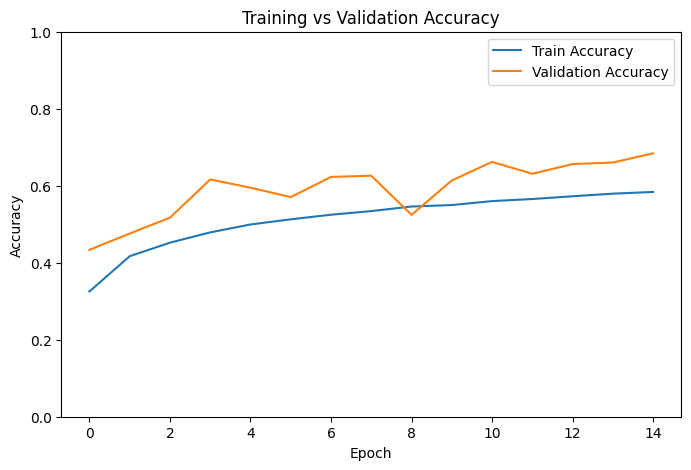

In [ ]:
# Plot Accuracy
# =========================

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.ylim(0,1)
plt.show()



In [ ]:
 #8️⃣ Evaluate Model
# =========================

test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Final Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.6808 - loss: 0.9186
Final Test Accuracy: 0.6840999722480774


In [ ]:
# # 9️⃣ External Image Prediction
# # =========================

# def predict_external_image(image_path):

#     # Load ORIGINAL image (no resize)
#     original_img = tf.keras.preprocessing.image.load_img(image_path)

#     # Create resized copy ONLY for model
#     resized_img = original_img.resize((32, 32))

#     img_array = tf.keras.preprocessing.image.img_to_array(resized_img)
#     img_array = img_array.astype("float32") / 255.0
#     img_array = np.expand_dims(img_array, axis=0)

#     prediction = model.predict(img_array, verbose=0)

#     predicted_class_index = np.argmax(prediction)
#     predicted_class = class_names[predicted_class_index]
#     confidence = float(np.max(prediction))

#     # Show ORIGINAL image
#     plt.imshow(original_img)
#     plt.title(f"Predicted: {predicted_class} ({confidence:.2f})")
#     plt.axis("off")
#     plt.show()

#     print("Predicted Class:", predicted_class)
#     print("Confidence:", confidence)

# predict_external_image("/content/images (1).jpg")

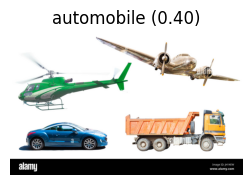

Image: cnn1.jpg
Predicted: automobile
Confidence: 0.40297120809555054
----------------------------------------


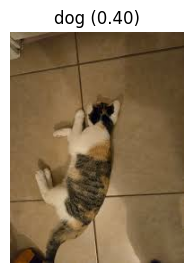

Image: images.jpg
Predicted: dog
Confidence: 0.39585262537002563
----------------------------------------


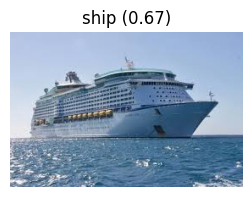

Image: ship_cnn.jpg
Predicted: ship
Confidence: 0.6669086813926697
----------------------------------------


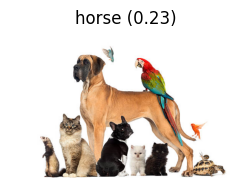

Image: cnn10.jpg
Predicted: horse
Confidence: 0.22508880496025085
----------------------------------------


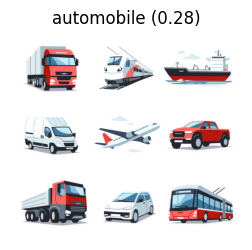

Image: cnn6.jpg
Predicted: automobile
Confidence: 0.2763568162918091
----------------------------------------


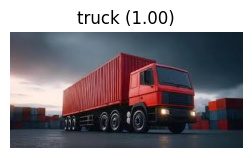

Image: truck_cnn.jpg
Predicted: truck
Confidence: 0.9993336796760559
----------------------------------------


IsADirectoryError: [Errno 21] Is a directory: '/content/testImages/.ipynb_checkpoints'

In [25]:
import os

def predict_folder(folder_path):

    for file_name in os.listdir(folder_path):

        image_path = os.path.join(folder_path, file_name)

        original_img = tf.keras.preprocessing.image.load_img(image_path)
        resized_img = original_img.resize((32, 32))

        img_array = tf.keras.preprocessing.image.img_to_array(resized_img)
        img_array = img_array.astype("float32") / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        prediction = model.predict(img_array, verbose=0)

        predicted_class_index = np.argmax(prediction)
        predicted_class = class_names[predicted_class_index]
        confidence = float(np.max(prediction))

        plt.figure(figsize=(3,3))
        plt.imshow(original_img)
        plt.title(f"{predicted_class} ({confidence:.2f})")
        plt.axis("off")
        plt.show()

        print("Image:", file_name)
        print("Predicted:", predicted_class)
        print("Confidence:", confidence)
        print("-" * 40)

predict_folder("/content/testImages")

['cnn1.jpg', 'images.jpg', 'ship_cnn.jpg', 'cnn10.jpg', 'cnn6.jpg', 'truck_cnn.jpg', '.ipynb_checkpoints', 'cnn5.jpg', 'bird_cnn_input.jpg', 'cnn8.jpg', 'airplane_cnn.jpg', 'cnn9.jpg', 'images (1).jpg', 'cnn7.jpg']


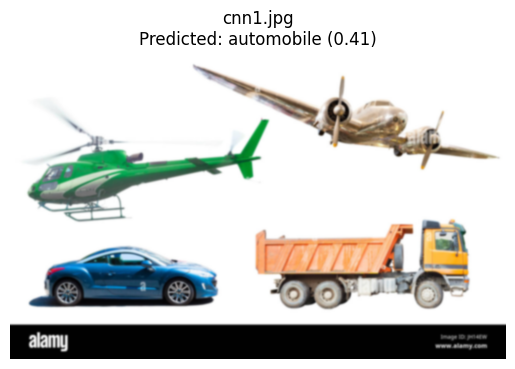

Image: cnn1.jpg
Predicted Class: automobile
Confidence: 0.406815767288208
----------------------------------------


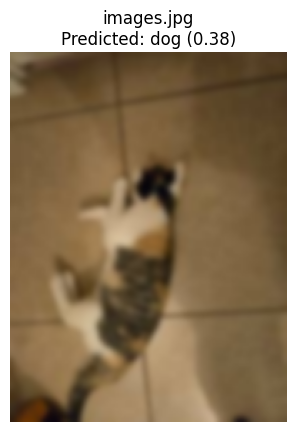

Image: images.jpg
Predicted Class: dog
Confidence: 0.37849095463752747
----------------------------------------


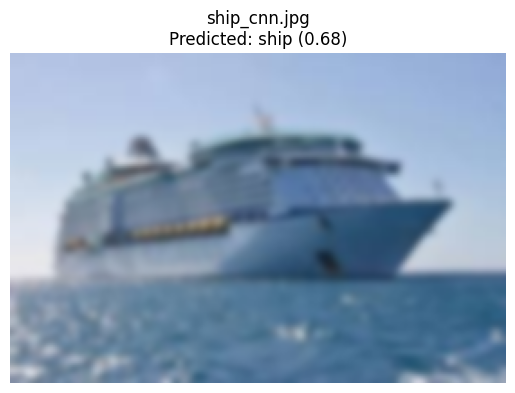

Image: ship_cnn.jpg
Predicted Class: ship
Confidence: 0.6792623996734619
----------------------------------------


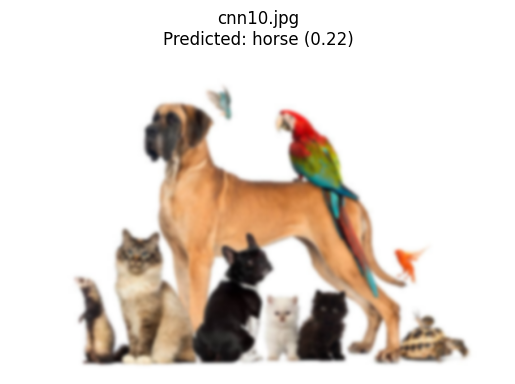

Image: cnn10.jpg
Predicted Class: horse
Confidence: 0.2208581119775772
----------------------------------------


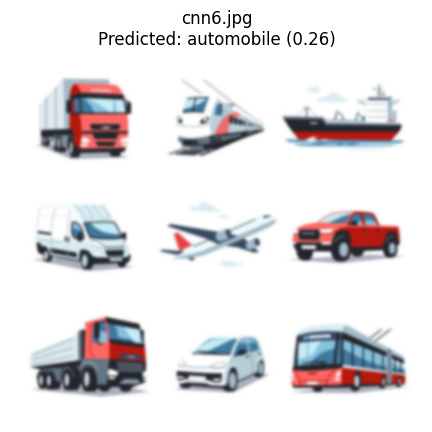

Image: cnn6.jpg
Predicted Class: automobile
Confidence: 0.262323796749115
----------------------------------------


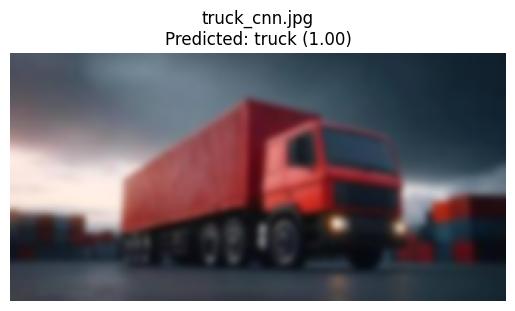

Image: truck_cnn.jpg
Predicted Class: truck
Confidence: 0.9989387392997742
----------------------------------------


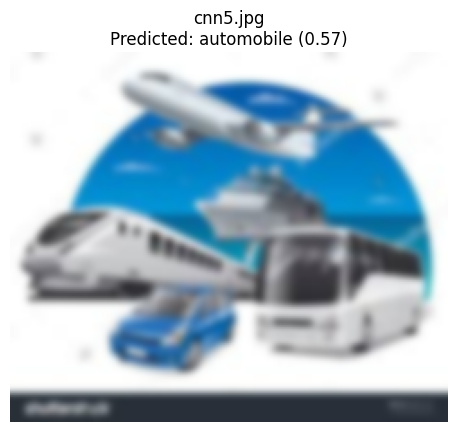

Image: cnn5.jpg
Predicted Class: automobile
Confidence: 0.5653143525123596
----------------------------------------


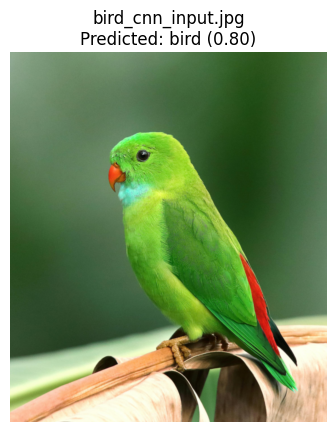

Image: bird_cnn_input.jpg
Predicted Class: bird
Confidence: 0.8039366006851196
----------------------------------------


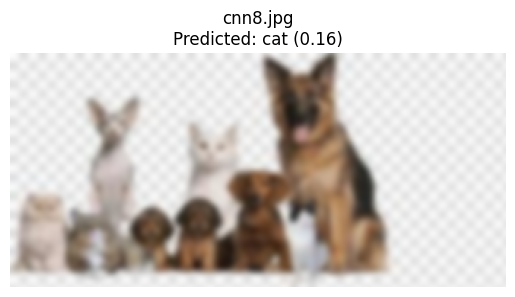

Image: cnn8.jpg
Predicted Class: cat
Confidence: 0.15659821033477783
----------------------------------------


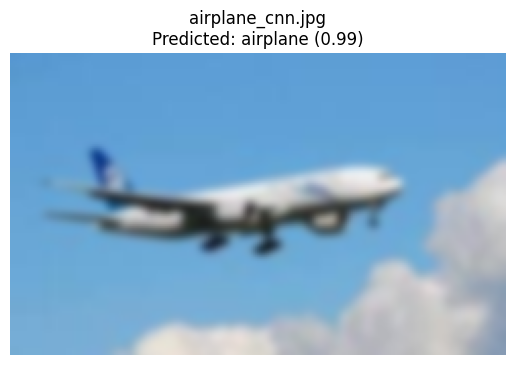

Image: airplane_cnn.jpg
Predicted Class: airplane
Confidence: 0.9884054660797119
----------------------------------------


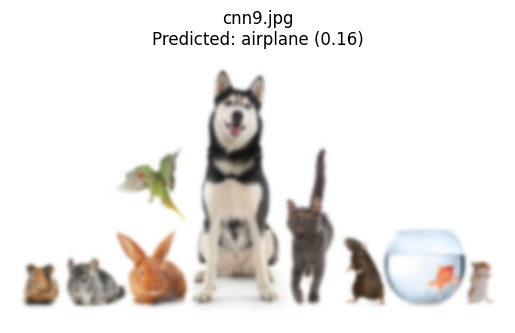

Image: cnn9.jpg
Predicted Class: airplane
Confidence: 0.16434194147586823
----------------------------------------


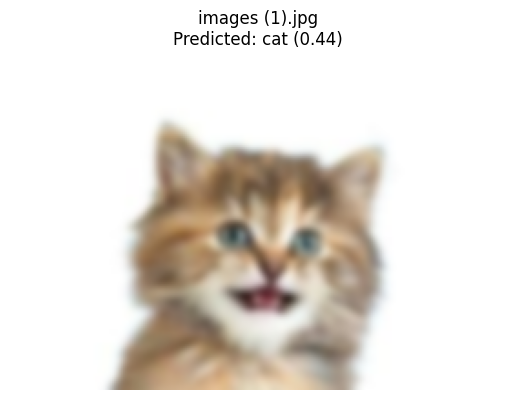

Image: images (1).jpg
Predicted Class: cat
Confidence: 0.43629613518714905
----------------------------------------


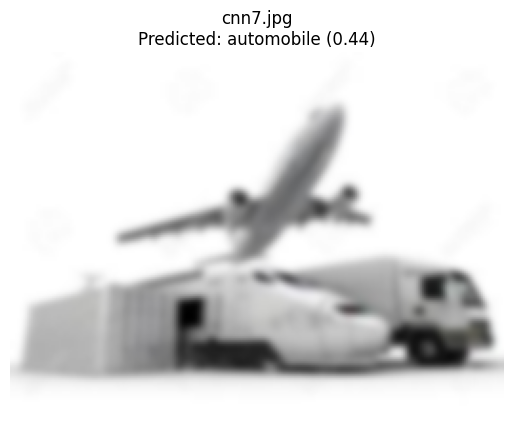

Image: cnn7.jpg
Predicted Class: automobile
Confidence: 0.4366680085659027
----------------------------------------


In [26]:
# # The below for blur images

# from PIL import ImageFilter
# def predict_external_image(image_path, blur_radius=0):

#     # Load ORIGINAL image
#     original_img = tf.keras.preprocessing.image.load_img(image_path)

#     # 🔹 Apply blur if radius > 0
#     if blur_radius > 0:
#         original_img = original_img.filter(
#             ImageFilter.GaussianBlur(radius=blur_radius)
#         )

#     # Resize for model
#     resized_img = original_img.resize((32, 32))

#     img_array = tf.keras.preprocessing.image.img_to_array(resized_img)
#     img_array = img_array.astype("float32") / 255.0
#     img_array = np.expand_dims(img_array, axis=0)

#     prediction = model.predict(img_array, verbose=0)

#     predicted_class_index = np.argmax(prediction)
#     predicted_class = class_names[predicted_class_index]
#     confidence = float(np.max(prediction))

#     # Show image
#     plt.imshow(original_img)
#     plt.title(f"Predicted: {predicted_class} ({confidence:.2f})")
#     plt.axis("off")
#     plt.show()

#     print("Predicted Class:", predicted_class)
#     print("Confidence:", confidence)


# # Light blur
# predict_external_image("/content/truck_cnn.jpg", blur_radius=2)


import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import ImageFilter

def predict_external_folder(folder_path, blur_radius=0):

    # Loop through all files in folder
    for filename in os.listdir(folder_path):

        # Process only image files
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):

            image_path = os.path.join(folder_path, filename)

            # Load ORIGINAL image
            original_img = tf.keras.preprocessing.image.load_img(image_path)

            # 🔹 Apply blur if radius > 0
            if blur_radius > 0:
                original_img = original_img.filter(
                    ImageFilter.GaussianBlur(radius=blur_radius)
                )

            # Resize for model
            resized_img = original_img.resize((32, 32))

            img_array = tf.keras.preprocessing.image.img_to_array(resized_img)
            img_array = img_array.astype("float32") / 255.0
            img_array = np.expand_dims(img_array, axis=0)

            prediction = model.predict(img_array, verbose=0)

            predicted_class_index = np.argmax(prediction)
            predicted_class = class_names[predicted_class_index]
            confidence = float(np.max(prediction))

            # Show image
            plt.imshow(original_img)
            plt.title(f"{filename}\nPredicted: {predicted_class} ({confidence:.2f})")
            plt.axis("off")
            plt.show()

            print("Image:", filename)
            print("Predicted Class:", predicted_class)
            print("Confidence:", confidence)
            print("-" * 40)


# 🔹 Example Usage
print(os.listdir("/content/testImages"))
predict_external_folder("/content/testImages", blur_radius=2)
